In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pickle
import os, sys
import torch
from matplotlib.lines import Line2D
from tqdm.autonotebook import tqdm
from matplotlib.colors import LinearSegmentedColormap
# Root project
project_root = os.path.abspath(os.path.join(os.getcwd(), "../../.."))

if project_root not in sys.path:
    sys.path.append(project_root)

print("Project root added to sys.path:", project_root)

from envs import *
from basal_ganglia import *
from stn_gpe import *

# filter warnings
import warnings
warnings.filterwarnings("ignore")



plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],  # Times for publication
    "font.size": 8,                    # Base font size
    "axes.labelsize": 8,              # Axis label font size
    "axes.labelweight": "bold",
    "font.weight": "bold",   
    "axes.titlesize":8,              # Axis title (not fig title)
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize":8,              # Legend font size

    "figure.dpi": 300,                 # Display resolution
    "savefig.dpi": 300,                # Save resolution
    "figure.constrained_layout.use": True,  # Better spacing than tight_layout

    "axes.linewidth": 0.8,             # Thin but clear axes lines
    "lines.linewidth": 1.2,
    "lines.markersize": 5,

    "axes.spines.top": False,
    "axes.spines.right": False,

    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,

    "legend.frameon": False,
    "legend.handlelength": 2.0,        # Slightly longer legend lines
    "legend.handletextpad": 0.5,

    "pdf.fonttype": 42,                # Embed editable fonts in PDF
    "ps.fonttype": 42
})



/var/folders/9v/hs9qlpdx4791kpqgpt09stch0000gn/T/ipykernel_16912/1253422274.py:7: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


Project root added to sys.path: /Users/charithapalika/Desktop/Lab projects/Decision Making/light_house_DBS_decision_making


In [2]:
yaml_path = os.path.join(project_root, 'params', 'decision_making_task_params', 'non_stationary_bandits', 'params.yaml')
params = load_yaml(yaml_path)

# --------------------------------------------------
# Single-run settings
# This notebook runs ONE condition and ONE del_lim value at a time.
# Change these two variables before running a condition.
# Suggested CONDITION_NAME values: 'PD', 'sDBS', 'Sector DBS'
# --------------------------------------------------
CONDITION_NAME = 'Normal'
DEL_LIM_CURRENT = None

# Change this path manually depending on CONDITION_NAME if needed.
# Example: params_PD.yaml, params_PD_sDBS.yaml, params_PD_sector_DBS.yaml, etc.
STN_DATA_path = os.path.join(project_root, 'params', 'stn_gpe_params', 'params_Normal.yaml')

# Accumulated metrics file. Each single run updates this file using
# CONDITION_NAME and DEL_LIM_CURRENT as keys. Only entropy+switching and Q-error are saved.
METRICS_SAVE_DIR = os.path.join(project_root, 'results', 'decision_making_tasks', 'data', 'non_stationary_bandits')
os.makedirs(METRICS_SAVE_DIR, exist_ok=True)
METRICS_SAVE_FILE = os.path.join(METRICS_SAVE_DIR, 'nsb_choice_q_metrics_single_runs.pkl')

print('Running condition:', CONDITION_NAME)
print('Running del_lim:', DEL_LIM_CURRENT)
print('Metrics will be saved to:', METRICS_SAVE_FILE)


Running condition: Normal
Running del_lim: None
Metrics will be saved to: /Users/charithapalika/Desktop/Lab projects/Decision Making/light_house_DBS_decision_making/results/decision_making_tasks/data/non_stationary_bandits/nsb_choice_q_metrics_single_runs.pkl


In [3]:
TRIALS = params['TRIALS']
EPOCHS = params['EPOCHS']
BINS = params['NUM_BINS']
LR = params['LR'] 
NUM_ARMS =params['NUM_ARMS']
SCALING_FACTOR = params['SCALING_FACTOR']   
TIME_STAMP_CHANGE = params['TIME_STAMP_CHANGE']
BIN_SIZE = TRIALS//BINS
BIN_CHANGE = TIME_STAMP_CHANGE // BIN_SIZE

In [4]:
# --------------------------------------------------
# Task reward configuration
# Rewards are already normalized by SCALING_FACTOR here.
# These normalized values are used again for DP/Q-value error.
# --------------------------------------------------
MEAN_REWARD_BEFORE = np.array([20, 40, 25]) / SCALING_FACTOR
STD_REWARD_BEFORE = np.array([2, 2, 2]) / SCALING_FACTOR

# Case 1: larger reward difference after switch
MEAN_REWARD_AFTER = np.array([25, 30, 50]) / SCALING_FACTOR
STD_REWARD_AFTER = np.array([2, 2, 2]) / SCALING_FACTOR

# For Case 2, use this instead:
# MEAN_REWARD_AFTER = np.array([25, 35, 50]) / SCALING_FACTOR

env = NonStationaryEnv(
    num_arms = NUM_ARMS,
    mean_reward = MEAN_REWARD_BEFORE,
    std = STD_REWARD_BEFORE,
    mean_rew_change = MEAN_REWARD_AFTER,
    std_change = STD_REWARD_AFTER,
    time_stamp_change = TIME_STAMP_CHANGE
)

BEST_ARM_BEFORE = int(np.argmax(MEAN_REWARD_BEFORE))
BEST_ARM_AFTER = int(np.argmax(MEAN_REWARD_AFTER))

BEST_ARM = torch.zeros((EPOCHS, TRIALS), dtype=int)
BEST_ARM[:, :TIME_STAMP_CHANGE] = BEST_ARM_BEFORE
BEST_ARM[:, TIME_STAMP_CHANGE:] = BEST_ARM_AFTER


In [5]:
reward_monitor, arm_chosen_monitor, avg_counts,ip_monitor, dp_monitor,ep_monitor, _= train(env, 
                                                      trails = TRIALS, 
                                                      epochs = EPOCHS, 
                                                      lr = LR, 
                                                      bins = BINS,
                                                      STN_data = STN_DATA_path, 
                                                      d1_amp=0.5, #0.5,
                                                      d2_amp=0.45, #0.0029, 
                                                      gpi_threshold=0.1,
                                                      max_gpi_iters=50,
                                                      del_lim=DEL_LIM_CURRENT, train_IP = False, 
                                                      del_med = None, printing = None,
                                                      gpi_mean= 1, ep_0 = 0.3,
                                                      alpha_ep = 0.0,
                                                      eta_ep = 0.1,
                                                      baseline_ep = 0.0)


Running STN-GPe system


  0%|          | 0/50000 [00:00<?, ?it/s]

StdDev of STN: 0.3235673247504033, Mean of STN: 1.0


  0%|          | 0/100 [00:00<?, ?it/s]

0: dp: tensor([[0.2503, 0.2503, 0.2503]], grad_fn=<MulBackward0>), ip: tensor([[0.3900, 0.5700, 0.5400]]), gpi: tensor([[-0.2230, -0.2528, -0.1522]], grad_fn=<NegBackward0>), arm_chosen:2
1: dp: tensor([[0.2503, 0.2503, 0.2850]], grad_fn=<MulBackward0>), ip: tensor([[0.3300, 0.3000, 0.2900]]), gpi: tensor([[-0.1458, -0.2254, -0.1587]], grad_fn=<NegBackward0>), arm_chosen:0
2: dp: tensor([[0.2500, 0.2503, 0.3054]], grad_fn=<MulBackward0>), ip: tensor([[0.3800, 0.2500, 0.4900]]), gpi: tensor([[-0.2091, -0.1966, -0.1214]], grad_fn=<NegBackward0>), arm_chosen:2
3: dp: tensor([[0.2500, 0.2503, 0.2840]], grad_fn=<MulBackward0>), ip: tensor([[0.4900, 0.4200, 0.2900]]), gpi: tensor([[-0.1853, -0.1914, -0.0708]], grad_fn=<NegBackward0>), arm_chosen:2
4: dp: tensor([[0.2500, 0.2503, 0.2618]], grad_fn=<MulBackward0>), ip: tensor([[0.3200, 0.4000, 0.6100]]), gpi: tensor([[-0.1906, -0.1902, -0.1927]], grad_fn=<NegBackward0>), arm_chosen:1
5: dp: tensor([[0.2500, 0.2673, 0.2500]], grad_fn=<MulBackwa

## Analysis

In [6]:
mean_picks = {key: torch.mean(avg_counts[key], dim = 0) for key in list(avg_counts.keys())}
IP_avg = {key: torch.mean(ip_monitor[key], dim =0).detach().numpy() for key in list(ip_monitor.keys())}
DP_avg = {key: torch.mean(dp_monitor[key], dim =0).detach().numpy() for key in list(dp_monitor.keys())}
IP_var = np.std(np.stack(list(IP_avg.values()), axis=0),axis = 0)[:,0]
arm_chosen_monitor = arm_chosen_monitor.to(torch.int)

# Computing Accuracy
optimal_probs_per_bin_all = torch.zeros((EPOCHS, BINS))

for i in range(BINS):
    start, end = i * BIN_SIZE, (i + 1) * BIN_SIZE
    correct_choices = torch.sum(arm_chosen_monitor[:, start:end] == BEST_ARM[:,start:end], axis = 1)
    optimal_probs_per_bin_all[:, i] = (correct_choices / BIN_SIZE)

optimal_prob_per_bin = torch.mean(optimal_probs_per_bin_all,axis = 0)
last_bin_prob = optimal_prob_per_bin[-1].item()
mean_prob = torch.mean(optimal_prob_per_bin).item()
mean_reward = torch.mean(reward_monitor, axis = 0)

In [7]:
# ==================================================
# Choice variability and DP/Q-value error metrics only
# This cell is designed for ONE current run only.
# It computes metrics from variables already produced above:
# arm_chosen_monitor, dp_monitor, MEAN_REWARD_BEFORE, MEAN_REWARD_AFTER.
# ==================================================

def _to_numpy(x):
    """Convert tensor/list/scalar to numpy array."""
    if hasattr(x, "detach"):
        x = x.detach().cpu().numpy()
    return np.asarray(x)


def get_true_mean_rewards_by_trial(trials, num_arms, mean_before, mean_after, change_trial):
    """Return true normalized reward mean for each trial and arm. Shape: trials x num_arms."""
    true_means = np.zeros((trials, num_arms), dtype=float)
    true_means[:change_trial, :] = np.asarray(mean_before, dtype=float)
    true_means[change_trial:, :] = np.asarray(mean_after, dtype=float)
    return true_means


def dp_monitor_to_q_array(dp_monitor, num_arms):
    """
    Convert dp_monitor dictionary into Q array.
    Expected input: dp_monitor[arm].shape = epochs x trials x 1.
    Output: q_values.shape = epochs x trials x arms.
    """
    q_list = []
    for arm in range(num_arms):
        q_arm = _to_numpy(dp_monitor[arm])
        if q_arm.ndim == 3:
            q_arm = q_arm[:, :, 0]
        elif q_arm.ndim != 2:
            raise ValueError(f"dp_monitor[{arm}] has unexpected shape: {q_arm.shape}")
        q_list.append(q_arm)
    return np.stack(q_list, axis=-1)


def compute_choice_variability_metrics(arm_chosen_monitor, num_arms, window_size=15, alpha_entropy=0.7):
    """
    Entropy + switching from action sequences.
    Entropy = normalized Shannon entropy within rolling windows.
    Switching = fraction of trial-to-trial action changes within rolling windows.
    Combined = alpha_entropy * entropy + (1-alpha_entropy) * switching.
    """
    choices = _to_numpy(arm_chosen_monitor).astype(int)
    epochs, trials = choices.shape

    entropy = np.full((epochs, trials - window_size + 1), np.nan)
    switching = np.full((epochs, trials - window_size + 1), np.nan)

    for e in range(epochs):
        for start in range(trials - window_size + 1):
            w = choices[e, start:start + window_size]
            counts = np.bincount(w, minlength=num_arms).astype(float)
            probs = counts / np.sum(counts)
            probs_nonzero = probs[probs > 0]

            entropy[e, start] = -np.sum(probs_nonzero * np.log(probs_nonzero)) / np.log(num_arms) if num_arms > 1 else 0.0
            switching[e, start] = np.mean(w[1:] != w[:-1])

    combined_variability = alpha_entropy * entropy + (1 - alpha_entropy) * switching

    return {
        'window_size': window_size,
        'alpha_entropy': alpha_entropy,
        'mean_entropy': float(np.nanmean(entropy)),
        'mean_switching': float(np.nanmean(switching)),
        'mean_combined_variability': float(np.nanmean(combined_variability)),
        'entropy': entropy,
        'switching': switching,
        'combined_variability': combined_variability,
    }


def compute_q_error_metrics(dp_monitor, true_mean_rewards, num_arms):
    """
    Compute DP/Q-value error using dp_monitor as learned values.
    Q-error compares q_values[e, t, arm] with true_mean_rewards[t, arm].
    true_mean_rewards must be on the same normalized scale as dp_monitor.
    """
    q_values = dp_monitor_to_q_array(dp_monitor, num_arms)
    epochs, trials, arms = q_values.shape

    if true_mean_rewards.shape != (trials, arms):
        raise ValueError(f"true_mean_rewards should have shape {(trials, arms)}, got {true_mean_rewards.shape}")

    q_error = q_values - true_mean_rewards[None, :, :]
    q_rmse_by_epoch_trial = np.sqrt(np.mean(q_error ** 2, axis=2))

    return {
        'q_values': q_values,
        'true_mean_rewards': true_mean_rewards,
        'q_error': q_error,
        'q_rmse_by_epoch_trial': q_rmse_by_epoch_trial,
        'mean_q_rmse': float(np.nanmean(q_rmse_by_epoch_trial)),
    }


def _del_lim_key_label(del_lim_current):
    """Allow DEL_LIM_CURRENT=None for no delta limit."""
    if del_lim_current is None:
        return None, 'no_limit', 'No limit'
    return float(del_lim_current), float(del_lim_current), str(del_lim_current)


def compute_current_run_metrics(
    arm_chosen_monitor,
    dp_monitor,
    num_arms,
    trials,
    mean_reward_before,
    mean_reward_after,
    time_stamp_change,
    condition_name,
    del_lim_current,
    scaling_factor=None,
    window_size=15,
    alpha_entropy=0.7,
):
    """Compute only the two required metrics for the current single run."""
    true_mean_rewards = get_true_mean_rewards_by_trial(
        trials=trials,
        num_arms=num_arms,
        mean_before=mean_reward_before,
        mean_after=mean_reward_after,
        change_trial=time_stamp_change,
    )

    choice_metrics = compute_choice_variability_metrics(
        arm_chosen_monitor=arm_chosen_monitor,
        num_arms=num_arms,
        window_size=window_size,
        alpha_entropy=alpha_entropy,
    )

    q_metrics = compute_q_error_metrics(
        dp_monitor=dp_monitor,
        true_mean_rewards=true_mean_rewards,
        num_arms=num_arms,
    )

    del_lim_save, del_lim_key, del_lim_label = _del_lim_key_label(del_lim_current)

    return {
        'condition_name': condition_name,
        'del_lim': del_lim_save,
        'del_lim_key': del_lim_key,
        'del_lim_label': del_lim_label,
        'scaling_factor': scaling_factor,
        'mean_reward_before_normalized': np.asarray(mean_reward_before, dtype=float),
        'mean_reward_after_normalized': np.asarray(mean_reward_after, dtype=float),
        'time_stamp_change': int(time_stamp_change),
        'entropy_plus_switching': choice_metrics['mean_combined_variability'],
        'q_error': q_metrics['mean_q_rmse'],
        'CHOICE_VARIABILITY_METRICS': choice_metrics,
        'Q_ERROR_METRICS': q_metrics,
    }


def save_current_run_metrics(metrics_save_file, current_run_metrics):
    """
    Save/update a single-run metrics pkl.
    Structure: saved['runs'][condition_name][del_lim_key] = current_run_metrics.
    None delta limit is saved under key 'no_limit'.
    """
    if os.path.exists(metrics_save_file):
        with open(metrics_save_file, 'rb') as f:
            saved = pickle.load(f)
    else:
        saved = {'runs': {}}

    cond = current_run_metrics['condition_name']
    d = current_run_metrics.get('del_lim_key', current_run_metrics.get('del_lim'))
    if d is None:
        d = 'no_limit'

    if cond not in saved['runs']:
        saved['runs'][cond] = {}

    saved['runs'][cond][d] = current_run_metrics

    with open(metrics_save_file, 'wb') as f:
        pickle.dump(saved, f)

    print(f"Saved metrics: condition={cond}, del_lim={current_run_metrics['del_lim_label']}")
    print(f"File: {metrics_save_file}")
    return saved


In [8]:
# ==================================================
# Compute and save metrics for THIS current run only
# ==================================================

CURRENT_RUN_METRICS = compute_current_run_metrics(
    arm_chosen_monitor=arm_chosen_monitor,
    dp_monitor=dp_monitor,
    num_arms=NUM_ARMS,
    trials=TRIALS,
    mean_reward_before=MEAN_REWARD_BEFORE,
    mean_reward_after=MEAN_REWARD_AFTER,
    time_stamp_change=TIME_STAMP_CHANGE,
    condition_name=CONDITION_NAME,
    del_lim_current=DEL_LIM_CURRENT,
    scaling_factor=SCALING_FACTOR,
    window_size=15,
    alpha_entropy=0.7,
)

SAVED_METRICS = save_current_run_metrics(METRICS_SAVE_FILE, CURRENT_RUN_METRICS)

print('\nCurrent run summary')
print('-------------------')
print(f"Condition: {CURRENT_RUN_METRICS['condition_name']}")
print(f"Delta limit: {CURRENT_RUN_METRICS['del_lim_label']}")
print(f"Entropy + switching = {CURRENT_RUN_METRICS['entropy_plus_switching']:.4f}")
print(f"Q-value error       = {CURRENT_RUN_METRICS['q_error']:.4f}")


Saved metrics: condition=Normal, del_lim=No limit
File: /Users/charithapalika/Desktop/Lab projects/Decision Making/light_house_DBS_decision_making/results/decision_making_tasks/data/non_stationary_bandits/nsb_choice_q_metrics_single_runs.pkl

Current run summary
-------------------
Condition: Normal
Delta limit: No limit
Entropy + switching = 0.1156
Q-value error       = 0.0515


In [9]:
# ==================================================
# Plot accumulated metrics from saved single runs
# Run this after you have saved multiple conditions/del_lim values.
# ==================================================


def load_saved_single_run_metrics(metrics_save_file):
    with open(metrics_save_file, 'rb') as f:
        return pickle.load(f)


def _sort_saved_keys(keys):
    def key_func(k):
        if k == 'no_limit':
            return (1, float('inf'))
        try:
            return (0, float(k))
        except Exception:
            return (2, str(k))
    return sorted(keys, key=key_func)


def _key_label(k):
    return 'No limit' if k == 'no_limit' else str(k)


def plot_saved_metrics(metrics_save_file, condition_order=('PD', 'sDBS', 'Sector DBS')):
    saved = load_saved_single_run_metrics(metrics_save_file)

    conditions = [c for c in condition_order if c in saved['runs']]
    if len(conditions) == 0:
        raise ValueError('No saved conditions found. Run and save at least one condition first.')

    all_keys = []
    for cond in conditions:
        all_keys.extend(list(saved['runs'][cond].keys()))
    all_keys = _sort_saved_keys(set(all_keys))
    x_map = {k: i for i, k in enumerate(all_keys)}
    x_labels = [_key_label(k) for k in all_keys]

    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

    for cond in conditions:
        keys = _sort_saved_keys(saved['runs'][cond].keys())
        x = np.asarray([x_map[k] for k in keys], dtype=float)
        entropy_switching = np.asarray([saved['runs'][cond][k]['entropy_plus_switching'] for k in keys], dtype=float)
        q_error = np.asarray([saved['runs'][cond][k]['q_error'] for k in keys], dtype=float)

        axes[0].plot(x, entropy_switching, marker='o', linewidth=2, label=cond)
        axes[1].plot(x, q_error, marker='o', linewidth=2, label=cond)

    for ax in axes:
        ax.set_xticks(np.arange(len(all_keys)))
        ax.set_xticklabels(x_labels)
        ax.set_xlabel(r'$\delta_{lim}$')
        ax.grid(True, alpha=0.3)

    axes[0].set_title('Entropy + switching')
    axes[0].set_ylabel('Choice variability')

    axes[1].set_title('Q-value error')
    axes[1].set_ylabel('Q-RMSE')

    axes[0].legend(frameon=False)
    plt.suptitle('Choice variability and Q-value error across saved single runs', y=1.05)
    plt.tight_layout()
    plt.show()

    return saved

# Uncomment after you have saved multiple runs:
# saved_metrics = plot_saved_metrics(METRICS_SAVE_FILE)


Accuracy at last bin:  0.9909999966621399
Avg accuracy across bins:  0.8546000719070435


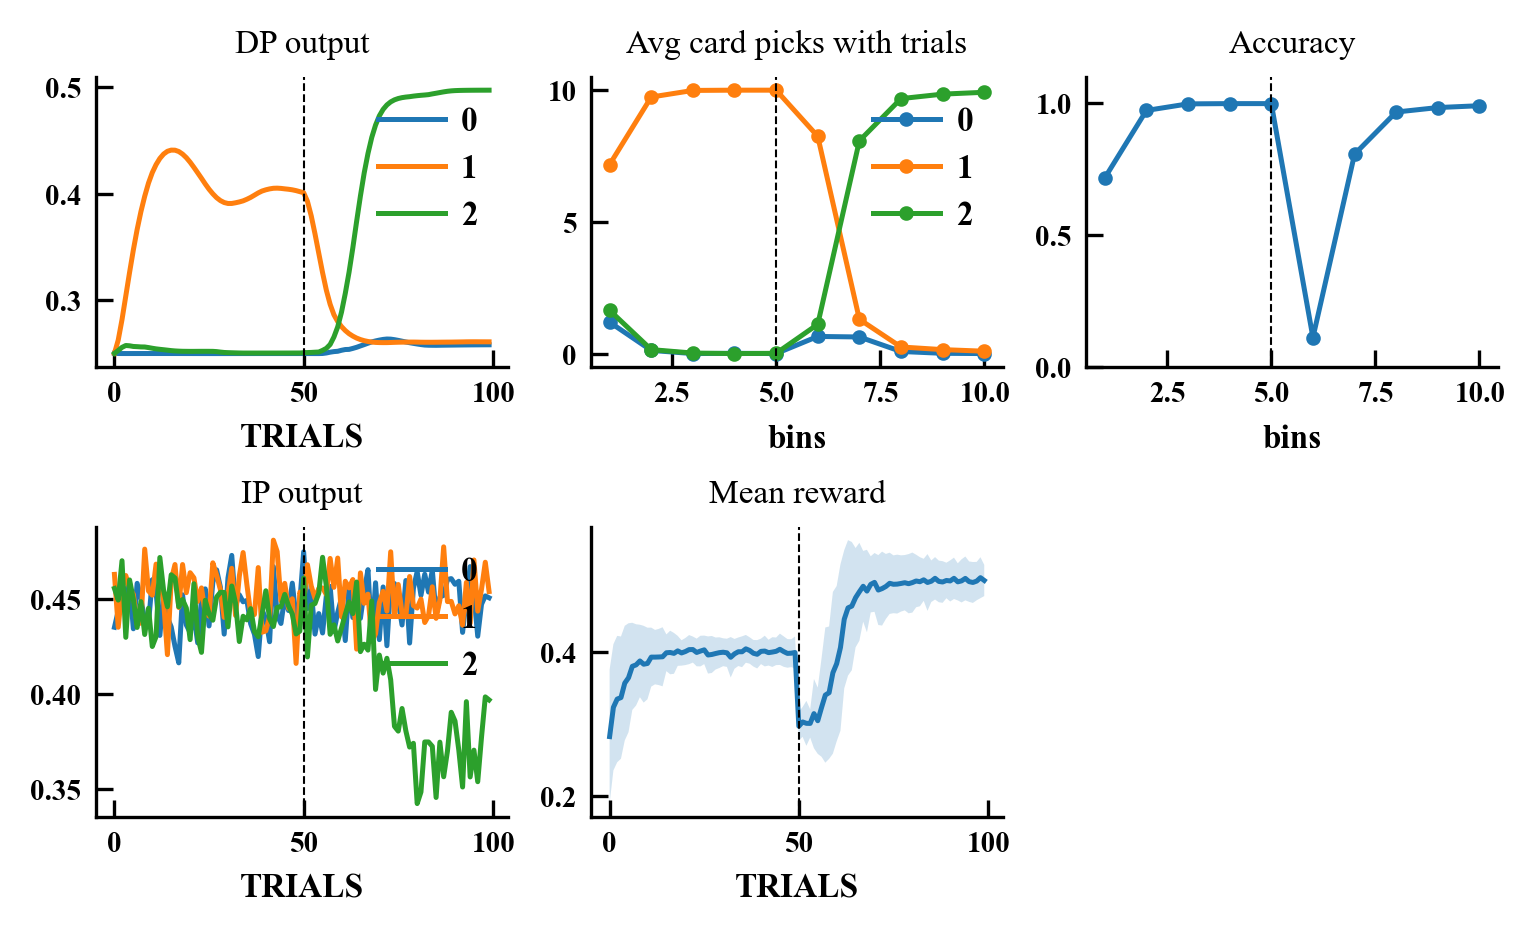

In [10]:
BIN = np.arange(BINS)+1


plt.figure(figsize=(5,3))
plt.subplot(231)
for i in DP_avg.keys():
    plt.plot(np.arange(TRIALS), DP_avg[i], label = i)
plt.axvline(x=TIME_STAMP_CHANGE, color='black', linestyle='--', linewidth=0.5)
plt.xlabel('TRIALS')
plt.title('DP output')
plt.legend(loc = 'upper right')

plt.subplot(232)

for i in mean_picks.keys():
    plt.plot(BIN,mean_picks[i], label = i, marker = '.', markersize = 5)
plt.axvline(x=BIN_CHANGE, color='black', linestyle='--', linewidth=0.5)
plt.title('Avg card picks with trials')
plt.xlabel('bins')
plt.legend(loc = 'upper right')

plt.subplot(233)
plt.plot(BIN, optimal_prob_per_bin, marker = '.', markersize = 5)
plt.axvline(x=BIN_CHANGE, color='black', linestyle='--', linewidth=0.5)
plt.title('Accuracy')
plt.ylim(0,1.1)
plt.xlabel('bins')

plt.subplot(234)
for i in IP_avg.keys():
    plt.plot(np.arange(TRIALS), IP_avg[i], label = i)
plt.axvline(x=TIME_STAMP_CHANGE, color='black', linestyle='--', linewidth=0.5)
plt.xlabel('TRIALS')
plt.title('IP output')
plt.legend(loc = 'upper right')

plt.subplot(235)
plt.plot(np.arange(TRIALS), mean_reward)
# show std as shaded region around
plt.fill_between(np.arange(TRIALS), mean_reward - torch.std(reward_monitor, axis = 0), mean_reward + torch.std(reward_monitor, axis = 0), alpha=0.2)
plt.axvline(x=TIME_STAMP_CHANGE, color='black', linestyle='--', linewidth=0.5)
plt.xlabel('TRIALS')
plt.title('Mean reward')
plt.legend(loc = 'upper right')


print('Accuracy at last bin: ',optimal_prob_per_bin[-1].item())
print('Avg accuracy across bins: ',torch.mean(optimal_prob_per_bin).item())

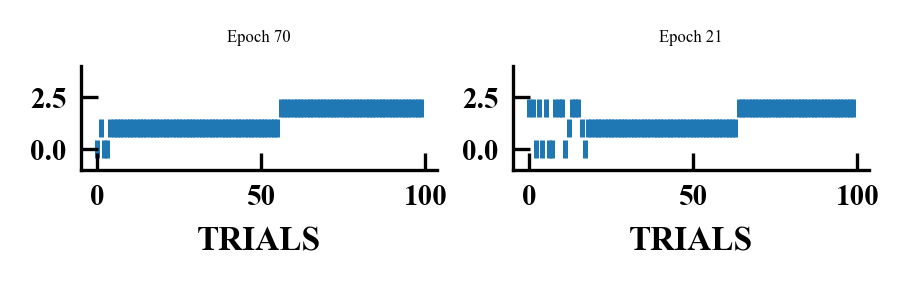

In [11]:
random_epochs = np.random.choice(np.arange(EPOCHS), size = 2)
i = 1
plt.figure(figsize=(3,1))
for e in random_epochs:
    plt.subplot(1,2,i)
    colors = np.where(np.isin(arm_chosen_monitor[e],[0,1]), 'r', 'g')
    plt.scatter(np.arange(TRIALS), arm_chosen_monitor[e], marker = '|', s = 20)
    plt.ylim(-1,4)
    plt.xlabel('TRIALS')
    plt.title(f'Epoch {e}', fontsize = 4)
    i+=1
# plt.suptitle('Card picks in each epoch')
plt.tight_layout()

In [12]:
# Print the two saved metrics for the current run
print("Current run values")
print("------------------")
print(f"Condition: {CURRENT_RUN_METRICS['condition_name']}")
print(f"Delta limit: {CURRENT_RUN_METRICS['del_lim_label']}")
print(f"Entropy + switching = {CURRENT_RUN_METRICS['entropy_plus_switching']:.4f}")
print(f"Q-value error       = {CURRENT_RUN_METRICS['q_error']:.4f}")


Current run values
------------------
Condition: Normal
Delta limit: No limit
Entropy + switching = 0.1156
Q-value error       = 0.0515
